# Critical Potts entanglement-spectrum flow

This notebook calculates the half-chain entanglement spectrum of the critical three-state Potts chain for several system sizes and selected boundary conditions. Its main figure follows the numerical plotting convention used for the Potts data in Figure 5 of A. M. Läuchli, *Operator content of real-space entanglement spectra at conformal critical points*.

Only finite-size scatter points are shown.

## 0. Imports

In [243]:
from pathlib import Path
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import tenpy
from tenpy.algorithms import dmrg
from tenpy.networks.mps import MPS


def find_project_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "potts_model_project", cwd.parent, cwd.parent / "potts_model_project"]
    for candidate in candidates:
        if (candidate / "potts_model" / "potts.py").is_file():
            return candidate
    raise RuntimeError("Could not locate the potts_model_project folder.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from potts_model import PottsChain

print("Project root:", PROJECT_ROOT)
print("TeNPy version:", tenpy.__version__)

Project root: /Users/Aditya/Desktop/Third Year Summer Project/potts_model_project
TeNPy version: 1.1.0


## 1. Definitions and Scaling

For a bipartition into regions $A$ and $B$, write the Schmidt decomposition as

$$
|\psi\rangle=\sum_\alpha s_\alpha |\alpha_A\rangle|\alpha_B\rangle.
$$

Here $s_\alpha$ is a **Schmidt value**. The corresponding eigenvalue of the reduced density matrix $\rho_A$ is

$$
\lambda_\alpha=s_\alpha^2,
$$

and this notebook defines the entanglement energy as

$$
\xi_\alpha=-\ln\lambda_\alpha=-2\ln s_\alpha.
$$

Thus, throughout this notebook, $\lambda$ means a reduced-density-matrix eigenvalue, **not** a Schmidt value.

For every boundary condition and every length $L$, sort the levels with multiplicity,

$$
\xi_0(L)\leq\xi_1(L)\leq\xi_2(L)\leq\cdots,
$$

then shift and rescale them as

$$
\widetilde\xi_n(L)=2\,\frac{\xi_n(L)-\xi_0(L)}{\xi_5(L)-\xi_0(L)}.
$$

For the free-boundary Potts spectrum, the expected first four **distinct level groups** are $0$, $2/3$, $5/3$, and $2$, with low-level multiplicities $1$, $2$, $2$, and $1$. The fourth distinct group is therefore the sixth sorted eigenvalue when multiplicity is counted, namely the zero-based entry $\xi_5$. Setting $\xi_5$ to 2 reproduces the normalization used for the three-state Potts spectra in Figure 5. A shift is necessary because the absolute entanglement-energy offset is non-universal; fixing one nonzero gap removes the remaining non-universal overall scale and allows spectra at different $L$ to be compared.

In the antiferromagnetic regime a different scaling has to be chosen but we cannot know what scaling to use before obtaining the data.

The horizontal coordinate is

$$
x_L=\frac{1}{\ln L}.
$$

Boundary-CFT arguments imply that the low entanglement gaps close approximately as $1/\ln L$, which is why the paper uses this variable. The thermodynamic limit would lie at $x_L=0$, but this notebook does not extrapolate to it.

## 2. Numerical parameters

In [244]:

L_values = [20, 40, 80, 100, 120, 140, 160, 200]
chi_max_values = [40, 50, 60, 70, 80, 80, 80, 80]
max_sweeps = 200

J = -1.0
h = -1.0
svd_min = 1e-11
max_E_err = 1e-9

n_levels_to_store = 40
n_levels_to_plot = 24
reference_rank = 5       # sixth eigenvalue = fourth distinct Potts level group
reference_value = 2.0

if any(L % 2 for L in L_values):
    raise ValueError("All L_values must be even for an equal half-chain cut.")
if any(L < 4 for L in L_values):
    raise ValueError("Every entry in L_values must be an integer of at least 4.")
if len(chi_max_values) != len(L_values):
    raise ValueError("chi_max_values must have the same length as L_values.")
if any(chi <= 0 for chi in chi_max_values):
    raise ValueError("Every entry in chi_max_values must be positive.")

run_configs = list(zip(L_values, chi_max_values))
if len(set(run_configs)) != len(run_configs):
    raise ValueError("Each (L, chi_max) pair must be unique.")
if n_levels_to_store <= reference_rank:
    raise ValueError("n_levels_to_store must include the reference level.")

print("Runs (L, chi_max):", run_configs)
print("J = h =", J)
print("max_sweeps:", max_sweeps)

Runs (L, chi_max): [(20, 40), (40, 50), (80, 60), (100, 70), (120, 80), (140, 80), (160, 80), (200, 80)]
J = h = -1.0
max_sweeps: 200


## 3. Boundary-condition selection

The reusable `PottsChain` accepts `1`, `2`, or `3` for a fixed edge; `-1`, `-2`, or `-3` for an edge that forbids that state; and `"free"` for a free edge. Edit only `selected_case_labels` to compare a different subset.

For the periodic case, `order="default"` is intentional. The central MPS cut must divide the physical ring into the two contiguous half-chains used in the paper. A folded MPS order makes the Hamiltonian cheaper but changes which physical sites lie on each side of the central MPS cut.

In [245]:
all_boundary_cases = {
    "free|free": {"left": "free", "right": "free"},
    "1|1": {"left": 1, "right": 1},
    "1|2": {"left": 1, "right": 2},
    "1|3": {"left": 1, "right": 3},
    "1|-1": {"left": 1, "right": -1},
    "1|-2": {"left": 1, "right": -2},
    "1|free": {"left": 1, "right": "free"},
    "-1|-1": {"left": -1, "right": -1},
    "-1|-2": {"left": -1, "right": -2},
    "-1|free": {"left": -1, "right": "free"},
    "periodic": {
        "left": "free",
        "right": "free",
        "periodic": True,
        "order": "default",
    },
}

selected_case_labels = ["free|free", "1|1", "1|2", "-1|-1", "-1|-2"]

unknown_labels = set(selected_case_labels) - set(all_boundary_cases)
if unknown_labels:
    raise KeyError(f"Unknown boundary labels: {sorted(unknown_labels)}")

boundary_cases = {
    label: all_boundary_cases[label]
    for label in selected_case_labels
}

boundary_cases

{'free|free': {'left': 'free', 'right': 'free'},
 '1|1': {'left': 1, 'right': 1},
 '1|2': {'left': 1, 'right': 2},
 '-1|-1': {'left': -1, 'right': -1},
 '-1|-2': {'left': -1, 'right': -2}}

## 4. Entanglement-spectrum helpers

TeNPy's direct entanglement spectrum is checked against $-2\ln s_\alpha$ from the central Schmidt values. The code also verifies that the density-matrix weights sum to one and that they reconstruct the central von Neumann entropy.

In [246]:
def central_entanglement_spectrum(psi):
    """Return all finite xi=-log(lambda) values at the equal half-chain cut."""
    if psi.L % 2:
        raise ValueError("Use an even L for an equal half-chain cut.")
    cut = psi.L // 2 - 1
    xi = np.asarray(psi.entanglement_spectrum()[cut], dtype=float)
    return np.sort(xi[np.isfinite(xi)])


def central_spectrum_from_schmidt_values(psi):
    """Independently calculate xi=-2 log(s) from central Schmidt values."""
    s = np.asarray(psi.get_SL(psi.L // 2), dtype=float)
    s = s[np.isfinite(s) & (s > 0.0)]
    return np.sort(-2.0 * np.log(s))


def normalize_spectrum(xi, rank, target=reference_value):
    """Shift xi[0] to zero and set xi[rank] to target."""
    xi = np.sort(np.asarray(xi, dtype=float))
    if len(xi) <= rank:
        raise ValueError(f"Need at least {rank + 1} levels for this normalization.")
    gap = xi[rank] - xi[0]
    if not np.isfinite(gap) or gap <= 1e-12:
        raise ValueError("The selected reference gap is zero or numerically unstable.")
    return target * (xi - xi[0]) / gap


def validate_central_spectrum(psi, xi, atol=2e-10):
    xi_from_s = central_spectrum_from_schmidt_values(psi)
    if len(xi) != len(xi_from_s) or not np.allclose(xi, xi_from_s, atol=atol, rtol=atol):
        raise RuntimeError("TeNPy's direct spectrum disagrees with -2 log(Schmidt values).")

    lambdas = np.exp(-xi)
    lambda_sum = float(np.sum(lambdas))
    entropy_from_spectrum = float(np.sum(lambdas * xi))
    central_entropy = float(psi.entanglement_entropy()[psi.L // 2 - 1])

    if not np.isclose(lambda_sum, 1.0, atol=2e-10, rtol=2e-10):
        raise RuntimeError(f"Central density-matrix eigenvalues sum to {lambda_sum}, not 1.")
    if not np.isclose(entropy_from_spectrum, central_entropy, atol=2e-10, rtol=2e-10):
        raise RuntimeError("The spectrum does not reconstruct the central entropy.")

    return {
        "lambda_sum": lambda_sum,
        "entropy_from_spectrum": entropy_from_spectrum,
        "central_entropy": central_entropy,
    }

## 5. Model builder and DMRG runner

The Hamiltonian uses the reusable project convention with $J=h=1$, the ferromagnetic critical point. The spectrum is taken at the cut between physical sites $L/2-1$ and $L/2$. For the periodic chain this produces a contiguous interval of length $L/2$ with two entanglement boundaries.

In [247]:
def build_model(L, case):
    return PottsChain.from_parameters(
        L=L,
        J=J,
        h=h,
        left_boundary=case["left"],
        right_boundary=case["right"],
        periodic=case.get("periodic", False),
        order=case.get("order", "default"),
    )


def antiferromagnetic_initial_state(model):
    """Alternating product state compatible with every restricted site."""
    physical_state = []
    L = model.lat.N_sites

    for site_index, allowed in enumerate(model.allowed_states_by_site):
        preferred = 1 if site_index % 2 == 0 else 2
        candidates = [preferred, 1, 2, 3]
        forbidden = {physical_state[-1]} if physical_state else set()

        # Look ahead to an exactly fixed right edge, so a third colour can
        # avoid an unnecessary equal-state bond (for example, 1|1 at even L).
        if site_index == L - 2:
            right_allowed = model.allowed_states_by_site[-1]
            if len(right_allowed) == 1:
                forbidden.add(right_allowed[0])

        # On a ring, also make the final site differ from the first one.
        if model.is_periodic and site_index == L - 1:
            forbidden.add(physical_state[0])

        selected = next(
            (state for state in candidates if state in allowed and state not in forbidden),
            allowed[0],
        )
        physical_state.append(selected)

    return [str(physical_state[index]) for index in model._mps_to_physical]


def run_dmrg_for_case(L, chi_for_L, label, case):
    model = build_model(L, case)
    if J > 0:
        initial_state = model.initial_product_state(bulk_state=1)
    else:
        initial_state = antiferromagnetic_initial_state(model)
    psi = MPS.from_product_state(
        model.lat.mps_sites(),
        initial_state,
        bc=model.lat.bc_MPS,
        unit_cell_width=model.lat.mps_unit_cell_width,
    )

    dmrg_params = {
        "mixer": True,
        "max_sweeps": max_sweeps,
        "N_sweeps_check": 1,
        "max_E_err": max_E_err,
        "max_N_sites_per_ring": model.lat.N_sites,
        "trunc_params": {
            "chi_max": chi_for_L,
            "svd_min": svd_min,
        },
    }

    engine = dmrg.TwoSiteDMRGEngine(psi, model, dmrg_params)
    start_time = time.perf_counter()
    energy, psi = engine.run()
    elapsed_seconds = time.perf_counter() - start_time

    if engine.shelve:
        final_status = "stopped at time limit"
    elif engine.is_converged():
        final_status = "converged"
    else:
        final_status = "sweep limit reached"
    xi_all = central_entanglement_spectrum(psi)
    checks = validate_central_spectrum(psi, xi_all)
    xi = xi_all[:n_levels_to_store]

    return {
        "label": label,
        "case": case,
        "L": L,
        "chi_max_requested": chi_for_L,
        "model": model,
        "psi": psi,
        "energy": float(np.real(energy)),
        "energy_per_site": float(np.real(energy) / L),
        "xi_raw": xi,
        "xi_shifted": xi - xi[0],
        "xi_scaled": normalize_spectrum(
            xi,
            rank=reference_rank,
            target=reference_value,
        ),
        "x_inv_log_L": 1.0 / np.log(L),
        "checks": checks,
        "chi": list(psi.chi),
        "sweeps": engine.sweeps,
        "status": final_status,
        "elapsed_seconds": elapsed_seconds,
    }

## 6. Run all selected cases

This is the expensive cell. Each entry of `chi_max_values` is paired with the entry at the same position in `L_values`. A run is identified by its `(L, chi_max)` pair, so the same system size may appear more than once with different bond dimensions. Runtime grows with the number of boundary cases, the system sizes, the selected bond dimensions, and `max_sweeps`.

To keep Jupyter output stable, this cell uses ordinary text rather than a live progress bar. It prints once when each run starts and once when it finishes, including the completed sweep count, achieved bond dimension, elapsed time, and convergence status. TeNPy 1.1.0 tests its stopping condition after `sweeps > max_sweeps`, so an unconverged run can complete `max_sweeps + 1` sweeps.

In [248]:
results = {label: {} for label in selected_case_labels}

for label, case in boundary_cases.items():
    for L, chi_for_L in run_configs:
        print(f"Running {label:>10}, L={L:>3}, chi_max={chi_for_L} ...", flush=True)
        result = run_dmrg_for_case(L, chi_for_L, label, case)
        results[label][(L, chi_for_L)] = result
        print(
            f"  Finished in {result['sweeps']} sweeps ({result['elapsed_seconds']:,.1f} s): "
            f"{result['status']}; E/L={result['energy_per_site']:.10f}, "
            f"max chi={max(result['chi'])}, "
            f"sum(lambda)={result['checks']['lambda_sum']:.12f}"
        )

print("Done.")

Running  free|free, L= 20, chi_max=40 ...
  Finished in 6 sweeps (2.2 s): converged; E/L=-0.5938128317, max chi=40, sum(lambda)=1.000000000000
Running  free|free, L= 40, chi_max=50 ...
  Finished in 11 sweeps (9.8 s): converged; E/L=-0.5995508974, max chi=50, sum(lambda)=1.000000000000
Running  free|free, L= 80, chi_max=60 ...
  Finished in 10 sweeps (26.5 s): converged; E/L=-0.6024453758, max chi=60, sum(lambda)=1.000000000000
Running  free|free, L=100, chi_max=70 ...
  Finished in 11 sweeps (47.3 s): converged; E/L=-0.6030263510, max chi=70, sum(lambda)=1.000000000000
Running  free|free, L=120, chi_max=80 ...
  Finished in 12 sweeps (74.1 s): converged; E/L=-0.6034140558, max chi=80, sum(lambda)=1.000000000000
Running  free|free, L=140, chi_max=80 ...
  Finished in 14 sweeps (95.5 s): converged; E/L=-0.6036911731, max chi=80, sum(lambda)=1.000000000000
Running  free|free, L=160, chi_max=80 ...
  Finished in 13 sweeps (105.5 s): converged; E/L=-0.6038991136, max chi=80, sum(lambda)=1.

final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=1.71e-05


  Finished in 15 sweeps (53.9 s): converged; E/L=-0.5947194247, max chi=60, sum(lambda)=1.000000000000
Running        1|1, L=100, chi_max=70 ...


final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=1.71e-05


  Finished in 41 sweeps (126.9 s): converged; E/L=-0.5968709731, max chi=70, sum(lambda)=1.000000000000
Running        1|1, L=120, chi_max=80 ...


...

  Finished in 44 sweeps (260.1 s): converged; E/L=-0.6031205167, max chi=80, sum(lambda)=1.000000000000
Running      -1|-1, L=160, chi_max=80 ...


final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=1.48e-05


  Finished in 90 sweeps (525.9 s): converged; E/L=-0.6034054000, max chi=80, sum(lambda)=1.000000000000
Running      -1|-1, L=200, chi_max=80 ...


final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=1.18e-05


  Finished in 201 sweeps (1,370.2 s): sweep limit reached; E/L=-0.6038017105, max chi=80, sum(lambda)=1.000000000000
Running      -1|-2, L= 20, chi_max=40 ...
  Finished in 4 sweeps (1.4 s): converged; E/L=-0.5899030381, max chi=40, sum(lambda)=1.000000000000
Running      -1|-2, L= 40, chi_max=50 ...
  Finished in 5 sweeps (5.3 s): converged; E/L=-0.5976642896, max chi=50, sum(lambda)=1.000000000000
Running      -1|-2, L= 80, chi_max=60 ...
  Finished in 8 sweeps (21.1 s): converged; E/L=-0.6015194668, max chi=60, sum(lambda)=1.000000000000
Running      -1|-2, L=100, chi_max=70 ...
  Finished in 8 sweeps (35.2 s): converged; E/L=-0.6022884262, max chi=70, sum(lambda)=1.000000000000
Running      -1|-2, L=120, chi_max=80 ...
  Finished in 9 sweeps (54.1 s): converged; E/L=-0.6028006782, max chi=80, sum(lambda)=1.000000000000
Running      -1|-2, L=140, chi_max=80 ...
  Finished in 12 sweeps (80.4 s): converged; E/L=-0.6031663820, max chi=80, sum(lambda)=1.000000000000
Running      -1|-2, 

## 7. Numerical diagnostics

These checks establish internal consistency, not convergence in $L$ or bond dimension. In particular, a successful row does not mean that its higher entanglement levels are quantitatively converged.

In [249]:
print(
    f"{'boundary':>10} {'L':>4} {'chi cap':>8} {'E/L':>15} {'max chi':>9} "
    f"{'sum(lambda)':>14} {'S spectrum - S TeNPy':>22}"
)
print("-" * 91)

for label in selected_case_labels:
    for L, chi_for_L in run_configs:
        result = results[label][(L, chi_for_L)]
        checks = result["checks"]
        entropy_difference = checks["entropy_from_spectrum"] - checks["central_entropy"]
        print(
            f"{label:>10} {L:4d} {chi_for_L:8d} {result['energy_per_site']:15.10f} "
            f"{max(result['chi']):9d} {checks['lambda_sum']:14.11f} "
            f"{entropy_difference:22.3e}"
        )

  boundary    L  chi cap             E/L   max chi    sum(lambda)   S spectrum - S TeNPy
-------------------------------------------------------------------------------------------
 free|free   20       40   -0.5938128317        40  1.00000000000             -1.110e-16
 free|free   40       50   -0.5995508974        50  1.00000000000              0.000e+00
 free|free   80       60   -0.6024453758        60  1.00000000000              0.000e+00
 free|free  100       70   -0.6030263510        70  1.00000000000              2.220e-16
 free|free  120       80   -0.6034140558        80  1.00000000000              0.000e+00
 free|free  140       80   -0.6036911731        80  1.00000000000              0.000e+00
 free|free  160       80   -0.6038991136        80  1.00000000000              2.220e-16
 free|free  200       80   -0.6041903751        80  1.00000000000              0.000e+00
       1|1   20       40   -0.5610246870        40  1.00000000000              0.000e+00
       1|1   40   

## 8. Separate the even and odd entanglement cuts

For a cut at MPS bond `b`, the left subsystem contains sites $0,\ldots,b-1$, so its size is $b$. In the antiferromagnetic chain the correlations are staggered, and the Schmidt spectrum depends strongly on whether this cut size is even or odd. In particular, our odd-cut spectra have a nearly degenerate lowest pair, while the even-cut spectra have a single lowest level followed by a nearly degenerate pair. Mixing these two sectors in one finite-size plot creates alternating branches and can make a normalization denominator artificially tiny.

For every saved DMRG state, the code below extracts **both** parities. It uses the exact half-chain cut when $L/2$ has the requested parity and otherwise uses the immediately adjacent cut at $L/2-1$. Thus each plot contains every system size, and the off-centre subsystem differs from half the chain by only one site. This reads Schmidt values already stored in each MPS; it does not rerun DMRG. The printed raw gaps should always be inspected before interpreting either scaled plot.


For h=-1, J=-1, the towers seem to be:
even: 0,1,1,3,4,4, ...
odd: 0,0,2,2,3,3, ...

In [250]:
def spectrum_at_cut(psi, cut, number_to_store=n_levels_to_store):
    """Return xi=-2 log(s) at an existing MPS bond; no DMRG is performed."""
    if not 1 <= cut < psi.L:
        raise ValueError(f"Cut {cut} is outside the internal bonds of an L={psi.L} MPS.")
    s = np.asarray(psi.get_SL(cut), dtype=float)
    s = s[np.isfinite(s) & (s > 0.0)]
    return np.sort(-2.0 * np.log(s))[:number_to_store]


def nearest_central_cut(L, parity):
    """Choose L//2 if possible, otherwise the adjacent cut to its left."""
    centre = L // 2
    return centre if centre % 2 == parity else centre - 1


def boundary_subplot_grid(panel_height, sharey=False, max_columns=2):
    """Large boundary-condition panels, wrapped over multiple rows."""
    number_of_cases = len(selected_case_labels)
    number_of_columns = min(max_columns, number_of_cases)
    number_of_rows = int(np.ceil(number_of_cases / number_of_columns))
    fig, axes = plt.subplots(
        number_of_rows,
        number_of_columns,
        figsize=(7.0 * number_of_columns, panel_height * number_of_rows),
        sharey=sharey,
        squeeze=False,
    )
    return fig, axes


def add_light_grid(ax):
    """Put a subtle grid behind the spectrum points."""
    ax.set_axisbelow(True)
    ax.grid(True, which="major", color="0.7", linewidth=0.8, alpha=0.28)


ordered_runs = sorted(run_configs, key=lambda config: (config[0], config[1]))
cut_spectra = {
    "even": {label: {} for label in selected_case_labels},
    "odd": {label: {} for label in selected_case_labels},
}

for label in selected_case_labels:
    for config in ordered_runs:
        result = results[label][config]
        for cut_name, parity in (("even", 0), ("odd", 1)):
            cut = nearest_central_cut(result["L"], parity)
            xi = spectrum_at_cut(result["psi"], cut)
            cut_spectra[cut_name][label][config] = {
                "cut": cut,
                "xi_raw": xi,
                "xi_shifted": xi - xi[0],
                "x_inv_log_L": result["x_inv_log_L"],
                "L": result["L"],
                "chi_max_requested": result["chi_max_requested"],
            }

        even = cut_spectra["even"][label][config]
        odd = cut_spectra["odd"][label][config]
        print(
            f"{label:>10}  L={result['L']:>3}, chi={result['chi_max_requested']:>4}  "
            f"even cut b={even['cut']:>3}: "
            f"{np.array2string(even['xi_shifted'][:6], precision=8)}  |  "
            f"odd cut b={odd['cut']:>3}: "
            f"{np.array2string(odd['xi_shifted'][:6], precision=8)}"
        )

 free|free  L= 20, chi=  40  even cut b= 10: [0.         1.38717768 1.38717777 4.31976869 6.02131892 6.02131944]  |  odd cut b=  9: [0.00000000e+00 5.35135342e-06 2.90706306e+00 2.91458084e+00
 4.45609838e+00 4.45609999e+00]
 free|free  L= 40, chi=  50  even cut b= 20: [0.         1.21199605 1.21199615 3.72743287 5.12254898 5.12254904]  |  odd cut b= 19: [0.00000000e+00 9.96798705e-06 2.49927738e+00 2.50049417e+00
 3.80751831e+00 3.80752158e+00]
 free|free  L= 80, chi=  60  even cut b= 40: [0.         1.07519451 1.07519486 3.28223265 4.47245938 4.47246394]  |  odd cut b= 39: [0.00000000e+00 2.22700715e-05 2.19679210e+00 2.19700127e+00
 3.33410289e+00 3.33410508e+00]
 free|free  L=100, chi=  70  even cut b= 50: [0.         1.03738514 1.03738544 3.16129004 4.29878246 4.29878265]  |  odd cut b= 49: [0.00000000e+00 1.14029014e-05 2.11497478e+00 2.11509402e+00
 3.20692463e+00 3.20692870e+00]
 free|free  L=120, chi=  80  even cut b= 60: [0.         1.00840025 1.0084004  3.06912319 4.16724548

### Raw unscaled spectra for each cut parity

The following two figures show the shifted entanglement energies $\xi_n-\xi_0$ directly, with **no division by a reference gap**. Even and odd cuts are displayed separately so that their different lowest multiplets are visible rather than mixed together. These plots are the appropriate place to check for tiny splittings, level crossings, and poorly converged higher levels before interpreting the scaled figures. The legend states the actual cut `b` used for each saved MPS.

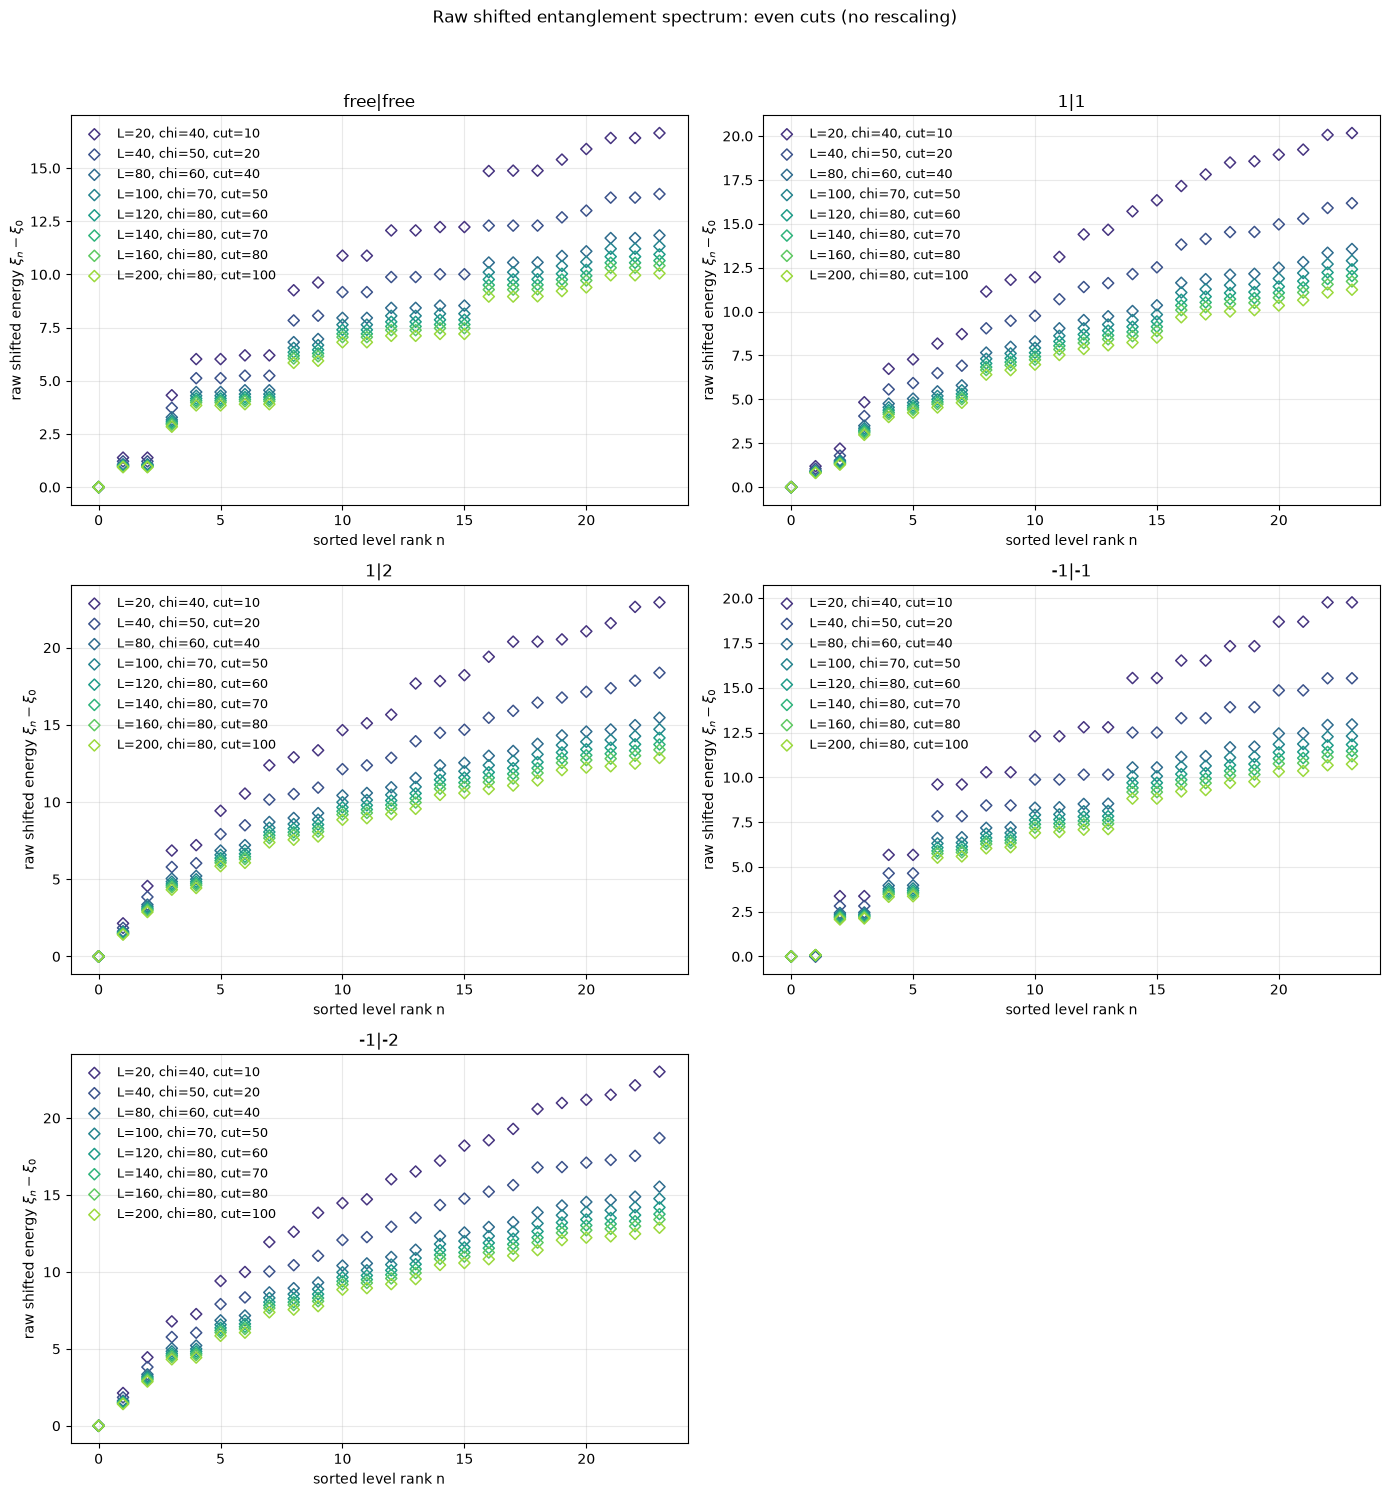

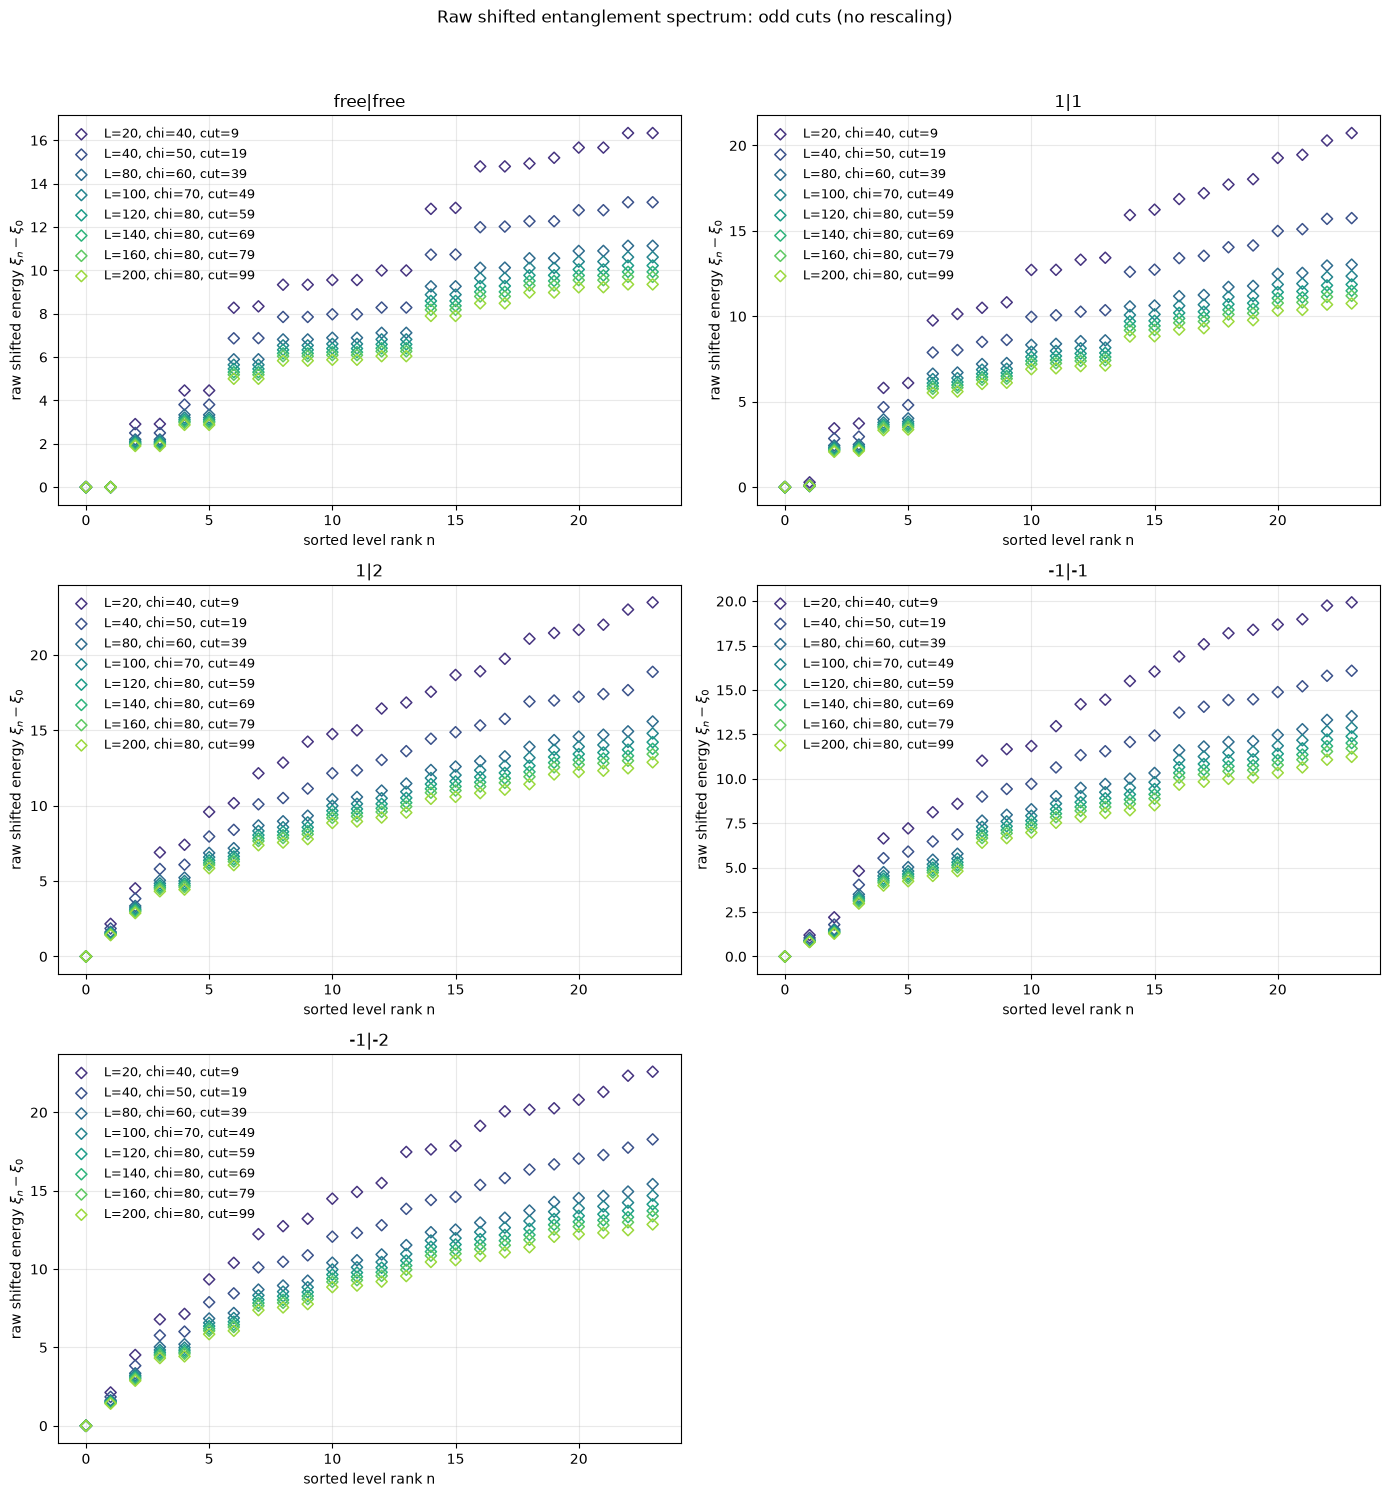

In [251]:
def plot_raw_spectra_for_cut(cut_name):
    fig, axes = boundary_subplot_grid(panel_height=5.0)
    run_colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(ordered_runs)))

    for ax, label in zip(axes.ravel(), selected_case_labels):
        for colour, config in zip(run_colours, ordered_runs):
            result = cut_spectra[cut_name][label][config]
            y = result["xi_shifted"][:n_levels_to_plot]
            ax.scatter(
                np.arange(len(y)), y,
                marker="D", s=32,
                facecolors="none", edgecolors=[colour], linewidths=1.1,
                label=(
                    f"L={result['L']}, chi={result['chi_max_requested']}, "
                    f"cut={result['cut']}"
                ),
            )
        ax.set_title(label)
        ax.set_xlabel("sorted level rank n")
        ax.set_ylabel(r"raw shifted energy $\xi_n-\xi_0$")
        add_light_grid(ax)
        ax.legend(frameon=False, fontsize=9)

    for ax in axes.ravel()[len(selected_case_labels):]:
        ax.set_visible(False)

    fig.suptitle(
        f"Raw shifted entanglement spectrum: {cut_name} cuts (no rescaling)",
        y=0.995,
    )
    fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))
    display(fig)
    plt.close(fig)


plot_raw_spectra_for_cut("even")
plot_raw_spectra_for_cut("odd")

### Choose the scaling separately for every boundary condition

Run the first code cell whenever `selected_case_labels` changes. It prints a complete, copyable `scaling_choices` assignment containing exactly the selected boundary conditions for both cut parities. Each tuple is `(reference_index, target_integer)`, meaning $\xi_{\mathrm{reference\ index}}$ is mapped to the chosen positive integer after subtracting $\xi_0$.

Copy the printed assignment into the following code cell and replace every `None`. The plotting cells validate the choices and state the normalization in each panel title. Index `0` is invalid because the shifted ground level is zero.

In [252]:
from pprint import pformat

scaling_template = {
    parity: {label: (None, None) for label in selected_case_labels}
    for parity in ("even", "odd")
}

print("Copy this assignment into the next code cell, then replace every None:\n")
print("scaling_choices = " + pformat(scaling_template, sort_dicts=False, width=100))


def scaling_for(parity, label):
    """Return and validate (reference_index, target_integer)."""
    try:
        choice = scaling_choices[parity][label]
    except (KeyError, TypeError) as error:
        raise KeyError(
            f"Missing {parity!r} scaling for {label!r}. "
            "Regenerate and copy the scaling template."
        ) from error

    if not isinstance(choice, (tuple, list)) or len(choice) != 2:
        raise ValueError(
            f"scaling_choices[{parity!r}][{label!r}] must be "
            "(reference_index, target_integer)."
        )

    reference_index, target_integer = choice
    if not isinstance(reference_index, (int, np.integer)) or reference_index < 1:
        raise ValueError(
            f"The reference index for {parity} / {label} must be an integer greater than 0."
        )
    if not isinstance(target_integer, (int, np.integer)) or target_integer < 1:
        raise ValueError(
            f"The target for {parity} / {label} must be a positive integer."
        )
    return int(reference_index), int(target_integer)

Copy this assignment into the next code cell, then replace every None:

scaling_choices = {'even': {'free|free': (None, None),
          '1|1': (None, None),
          '1|2': (None, None),
          '-1|-1': (None, None),
          '-1|-2': (None, None)},
 'odd': {'free|free': (None, None),
         '1|1': (None, None),
         '1|2': (None, None),
         '-1|-1': (None, None),
         '-1|-2': (None, None)}}


In [253]:
# Edit these entries after inspecting the raw spectra in Section 8.
# Each tuple is (reference_index, target_integer).
scaling_choices = {
    "even": {
        "free|free": (1, 1),
        "1|1": (1, 1),
        "1|2": (1, 1),
        "-1|-1": (2, 2),
        "-1|-2": (1, 1),
    },
    "odd": {
        "free|free": (2, 2),
        "1|1": (2, 2),
        "1|2": (1, 1),
        "-1|-1": (1, 1),
        "-1|-2": (1, 1),
    },
}

## 9. Even-cut scaling and plot

For each boundary condition, the even-cut plotting cell reads `(r, a) = scaling_choices["even"][label]` and applies

$$
\widetilde\xi_n^{\mathrm{even}}(L)
=a\frac{\xi_n-\xi_0}{\xi_r-\xi_0},
$$

The supplied entries $(1,1)$ are only starting choices; inspect the raw spectrum and edit each boundary condition independently. The panel title reports the choice actually used. After changing `scaling_choices`, rerun only this plotting cell—DMRG and spectrum extraction are not repeated. The horizontal coordinate remains $x_L=1/\ln L$, only points are drawn, and no extrapolated lines are added.

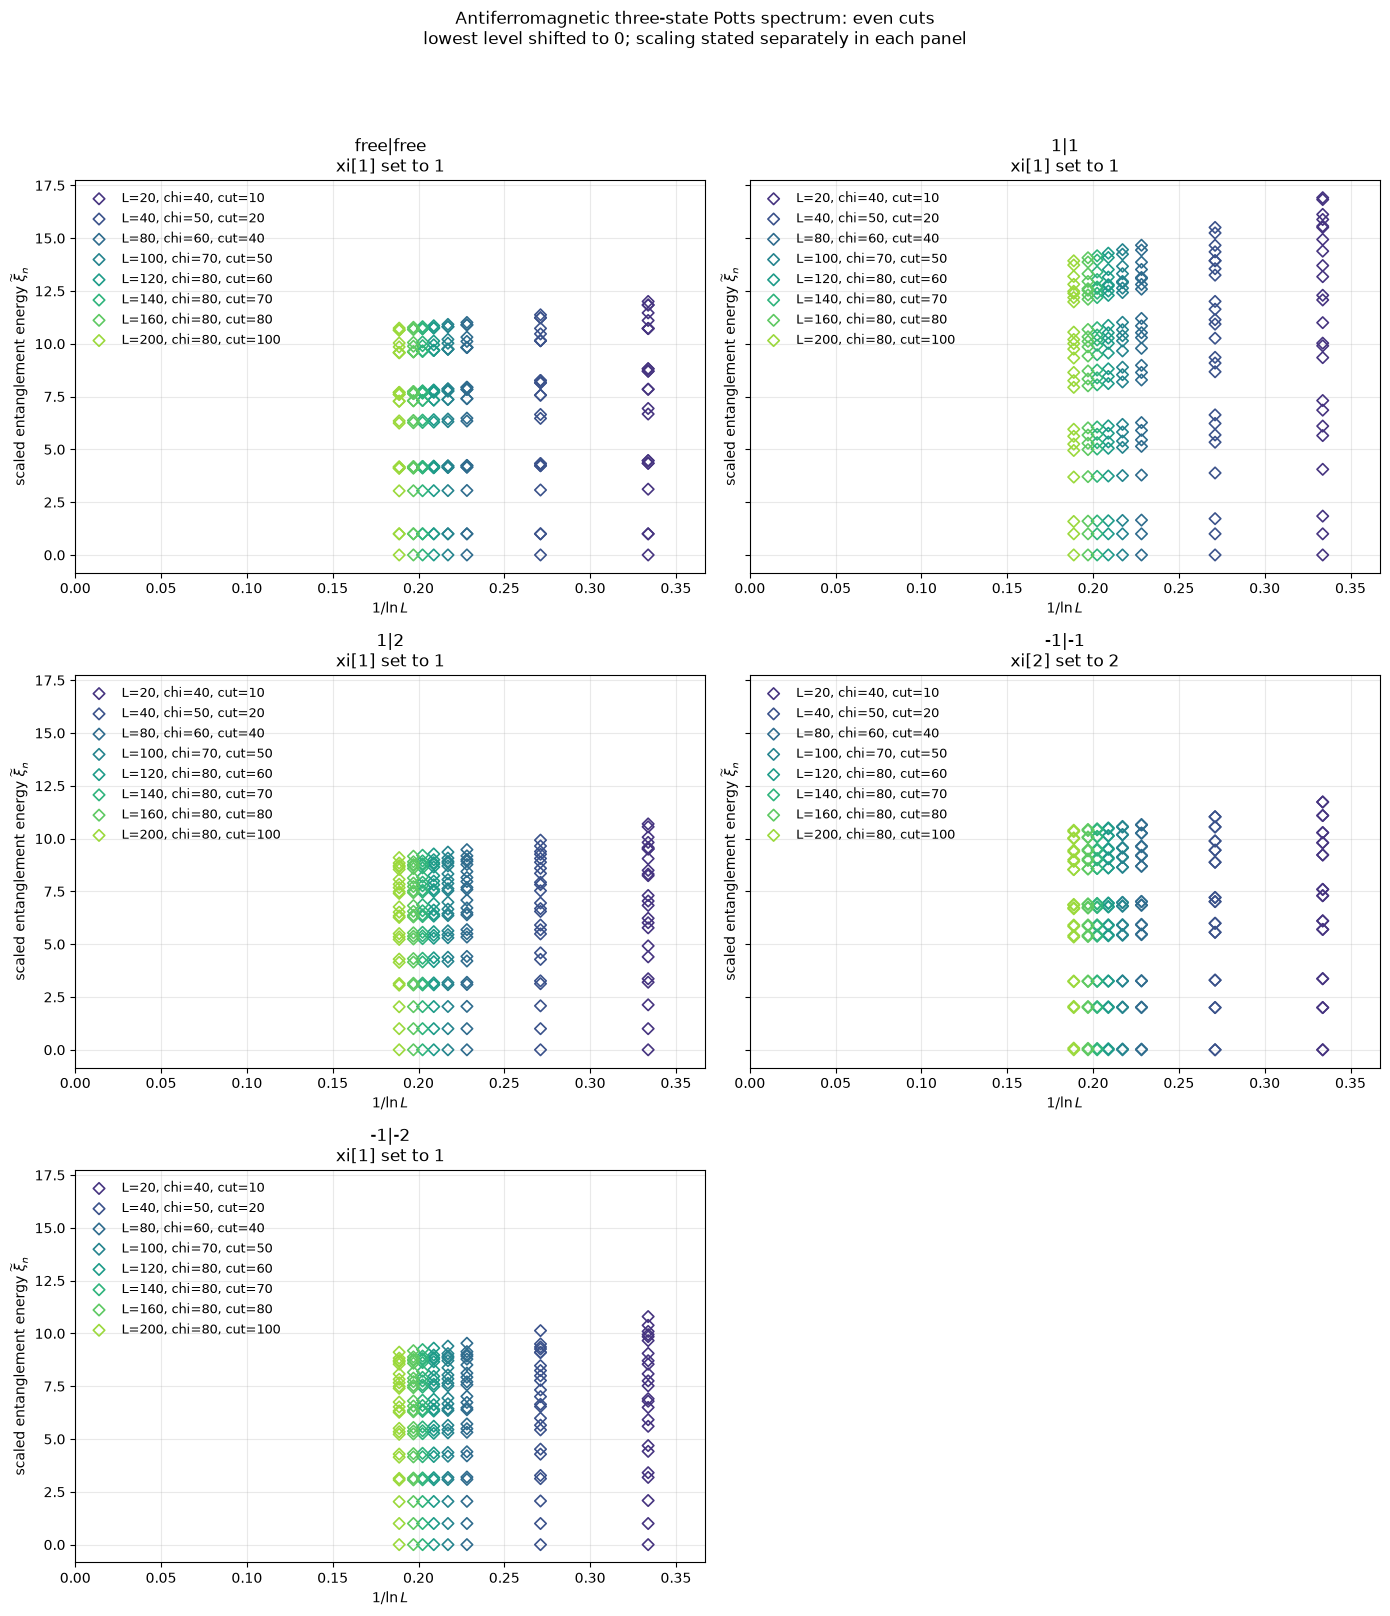

In [254]:
fig, axes = boundary_subplot_grid(panel_height=5.4, sharey=True)
run_colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(ordered_runs)))

for ax, label in zip(axes.ravel(), selected_case_labels):
    reference_index, target_integer = scaling_for("even", label)
    available = [cut_spectra["even"][label][config] for config in ordered_runs]

    for colour, result in zip(run_colours, available):
        shifted = result["xi_shifted"]
        if len(shifted) <= reference_index:
            raise ValueError(
                f"Even-cut normalization for {label} needs xi[{reference_index}], "
                f"but only {len(shifted)} levels are stored."
            )
        reference_gap = shifted[reference_index]
        if not np.isfinite(reference_gap) or reference_gap <= 0.0:
            raise ValueError(
                f"Invalid even-cut reference gap for {label} at xi[{reference_index}]."
            )
        y = (target_integer * shifted / reference_gap)[:n_levels_to_plot]
        x = np.full(len(y), result["x_inv_log_L"])
        ax.scatter(
            x, y,
            marker="D", s=34,
            facecolors="none", edgecolors=[colour], linewidths=1.2,
            label=(
                f"L={result['L']}, chi={result['chi_max_requested']}, "
                f"cut={result['cut']}"
            ),
        )

    ax.set_xlim(0.0, max(result["x_inv_log_L"] for result in available) * 1.10)
    ax.set_xlabel(r"$1/\ln L$")
    ax.set_ylabel(r"scaled entanglement energy $\widetilde{\xi}_n$")
    ax.set_title(f"{label}\nxi[{reference_index}] set to {target_integer}")
    add_light_grid(ax)
    ax.legend(frameon=False, fontsize=9)

for ax in axes.ravel()[len(selected_case_labels):]:
    ax.set_visible(False)

fig.suptitle(
    "Antiferromagnetic three-state Potts spectrum: even cuts\n"
    "lowest level shifted to 0; scaling stated separately in each panel",
    y=0.995,
)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))

## 10. Odd-cut scaling and plot

For each boundary condition, the odd-cut plotting cell reads `(r, a) = scaling_choices["odd"][label]` and applies

$$
\widetilde\xi_n^{\mathrm{odd}}(L)
=a\frac{\xi_n-\xi_0}{\xi_r-\xi_0},
$$

The supplied entries $(2,2)$ are only starting choices motivated by the current odd-cut lowest doublet; they are not assumed to be correct for every boundary condition. Inspect the raw spectra and edit each entry independently. Changing `scaling_choices` and rerunning this plotting cell does not rerun DMRG. Only points are shown; ranks are not connected or extrapolated.

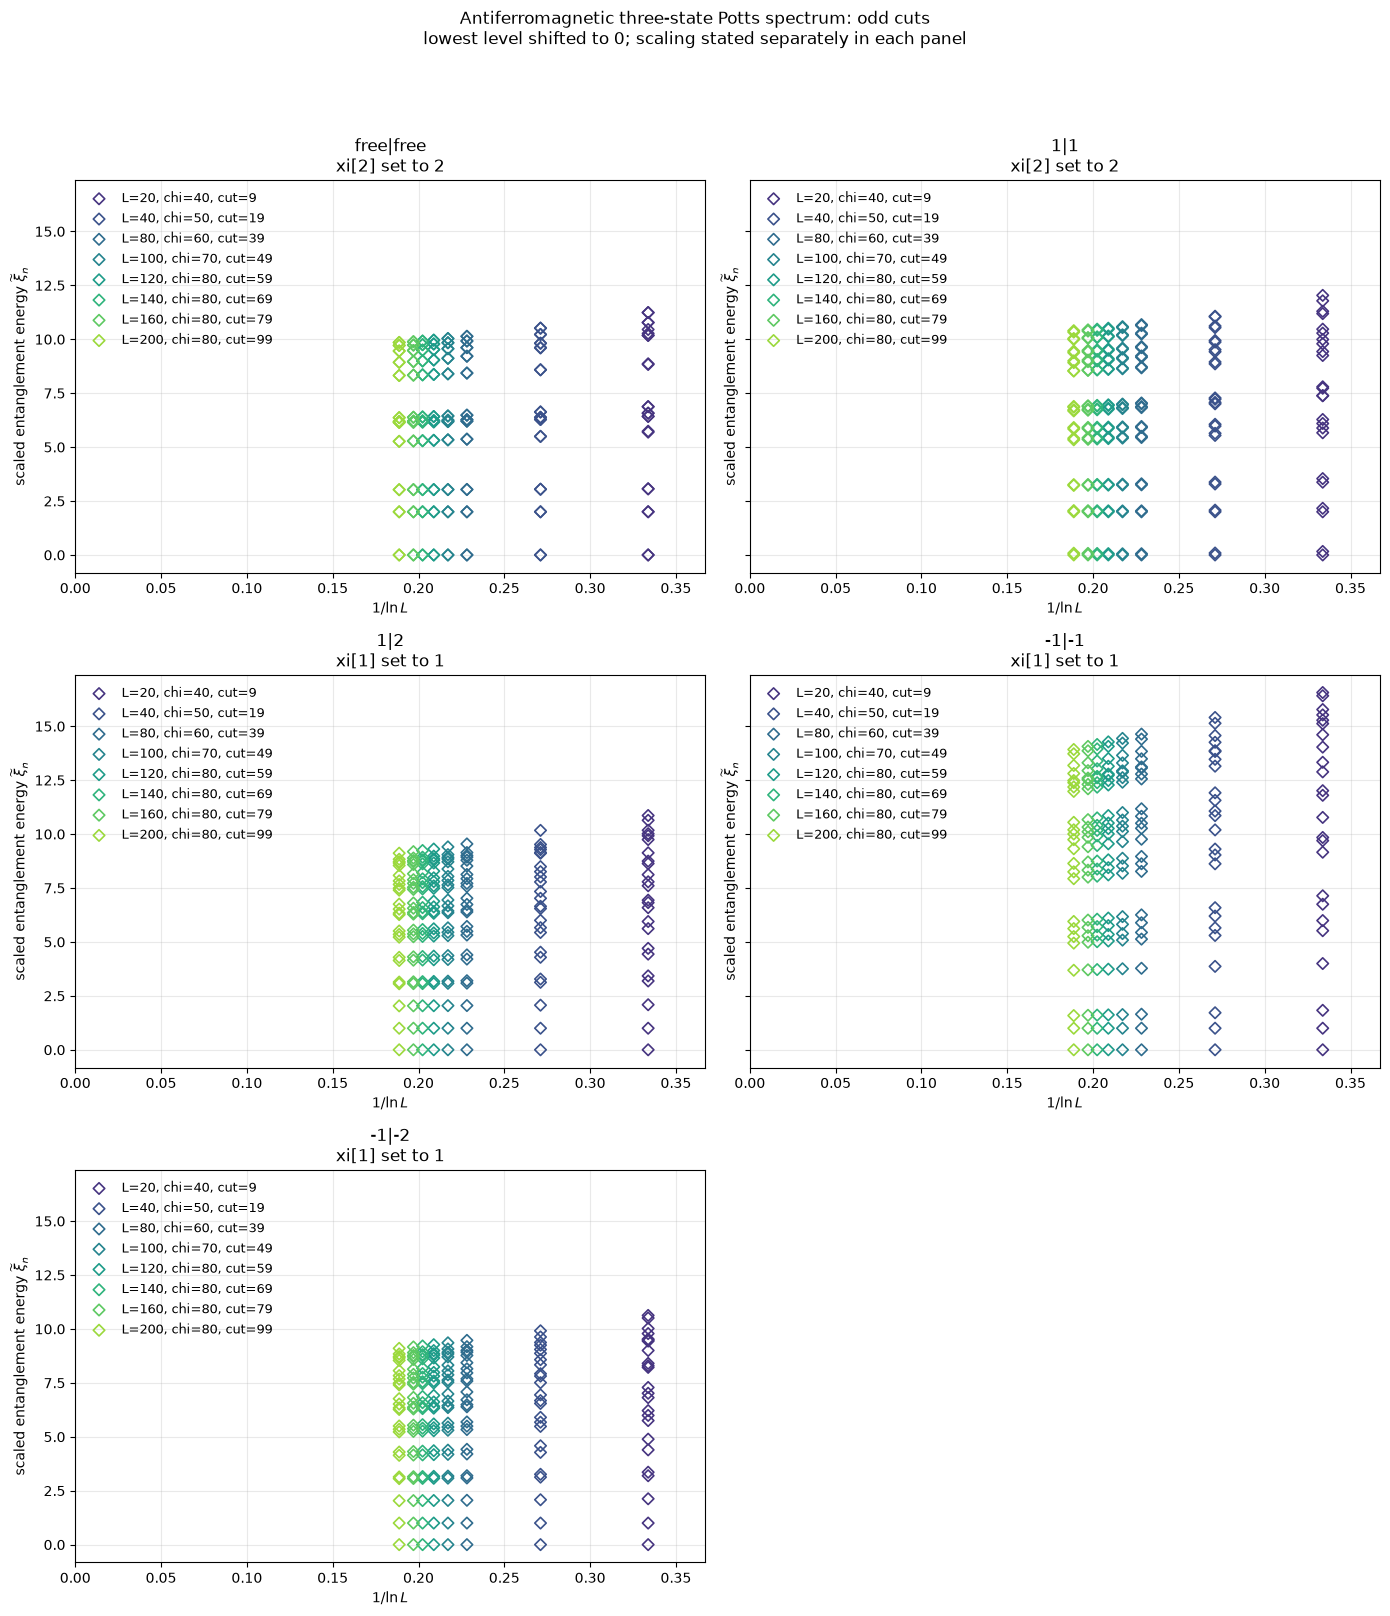

In [255]:
fig, axes = boundary_subplot_grid(panel_height=5.4, sharey=True)
run_colours = plt.cm.viridis(np.linspace(0.15, 0.85, len(ordered_runs)))

for ax, label in zip(axes.ravel(), selected_case_labels):
    reference_index, target_integer = scaling_for("odd", label)
    available = [cut_spectra["odd"][label][config] for config in ordered_runs]

    for colour, result in zip(run_colours, available):
        shifted = result["xi_shifted"]
        if len(shifted) <= reference_index:
            raise ValueError(
                f"Odd-cut normalization for {label} needs xi[{reference_index}], "
                f"but only {len(shifted)} levels are stored."
            )
        reference_gap = shifted[reference_index]
        if not np.isfinite(reference_gap) or reference_gap <= 0.0:
            raise ValueError(
                f"Invalid odd-cut reference gap for {label} at xi[{reference_index}]."
            )
        y = (target_integer * shifted / reference_gap)[:n_levels_to_plot]
        x = np.full(len(y), result["x_inv_log_L"])
        ax.scatter(
            x, y,
            marker="D", s=34,
            facecolors="none", edgecolors=[colour], linewidths=1.2,
            label=(
                f"L={result['L']}, chi={result['chi_max_requested']}, "
                f"cut={result['cut']}"
            ),
        )

    ax.set_xlim(0.0, max(result["x_inv_log_L"] for result in available) * 1.10)
    ax.set_xlabel(r"$1/\ln L$")
    ax.set_ylabel(r"scaled entanglement energy $\widetilde{\xi}_n$")
    ax.set_title(f"{label}\nxi[{reference_index}] set to {target_integer}")
    add_light_grid(ax)
    ax.legend(frameon=False, fontsize=9)

for ax in axes.ravel()[len(selected_case_labels):]:
    ax.set_visible(False)

fig.suptitle(
    "Antiferromagnetic three-state Potts spectrum: odd cuts\n"
    "lowest level shifted to 0; scaling stated separately in each panel",
    y=0.995,
)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))

## 11. Interpretation limits

At this stage the plot reveals only coarse finite-size trends. Much more computational power would be needed to be able to extract valuable information.

- Even and odd cuts are normalized separately because they exhibit different low-level multiplicities. These normalizations make each parity sector comparable across $L$; they do not by themselves identify the associated boundary-CFT characters.
- The off-centre cut has subsystem size $L/2-1$ rather than $L/2$. This one-site difference is deliberate: it preserves cut parity across all system sizes and becomes negligible relative to $L$ as the chain grows.
- When applying this notebook to a different coupling or physical boundary condition, inspect the printed raw gaps before assuming that the same reference levels remain appropriate.
- Low-lying levels generally converge before high levels. Increasing `n_levels_to_plot` can therefore display levels that are poorly converged even when the DMRG energy looks stable.

## 12. Check whether the cut dependence is mod 2 or mod 3

The even/odd plots above assume that the alternating spectrum is controlled by the parity of the cut size $b$. Because the local Potts Hilbert space has three states, it is also sensible to check whether the real pattern is instead controlled by $b\bmod 3$. Looking only at three residue classes would mix even and odd cuts, so this check records both quantities: **colour shows $b\bmod 3$ and marker shape shows $b\bmod 2$**. Equivalently, it resolves all six classes modulo $\operatorname{lcm}(2,3)=6$.

For each boundary condition, the code reads the existing converged $L=140$, $\chi_{\max}=70$ MPS and examines the thirteen cuts $b=L/2-6,\ldots,L/2+6$. This is wide enough to repeat every mod-6 class while remaining close to the centre of the chain. It performs **no DMRG**.

At each cut only the lowest entanglement energy is shifted to zero: $\xi_n(b)-\xi_0(b)$. The spectra are deliberately not rescaled independently, since doing so could manufacture an apparent agreement. If stacks with the same marker shape resemble one another, the effect is mainly mod 2; if stacks with the same colour resemble one another, it is mainly mod 3; if agreement requires both colour and marker, both effects are present (a mod-6 pattern). A slow drift with distance from the centre is expected and should not be confused with a residue-class effect.

In [256]:
from matplotlib.lines import Line2D


# This section only reads Schmidt values from an existing MPS; it never calls DMRG.
mod_check_config = (140, 70)  # (L, chi_max)
mod_check_half_window = 6
mod_check_levels = min(8, n_levels_to_store)

if mod_check_config not in run_configs:
    raise KeyError(
        f"The requested saved run {mod_check_config} is not in run_configs. "
        "Choose another existing (L, chi_max) pair; do not rerun DMRG for this check."
    )

mod_check_L, mod_check_chi = mod_check_config
mod_check_centre = mod_check_L // 2
mod_check_cuts = range(
    mod_check_centre - mod_check_half_window,
    mod_check_centre + mod_check_half_window + 1,
)

mod3_colours = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}
parity_markers = {0: "o", 1: "x"}

legend_handles = [
    Line2D(
        [0], [0], marker="s", linestyle="none", markersize=7,
        markerfacecolor=mod3_colours[residue], markeredgecolor=mod3_colours[residue],
        label=f"b mod 3 = {residue}",
    )
    for residue in range(3)
] + [
    Line2D(
        [0], [0], marker=parity_markers[parity], linestyle="none", markersize=7,
        markerfacecolor="none", markeredgecolor="0.3",
        label="even cut" if parity == 0 else "odd cut",
    )
    for parity in range(2)
]

fig, axes = boundary_subplot_grid(panel_height=5.4, sharey=False)

for ax, label in zip(axes.ravel(), selected_case_labels):
    if mod_check_config not in results[label]:
        raise KeyError(f"No saved MPS for {label!r} at {mod_check_config}.")

    psi = results[label][mod_check_config]["psi"]
    for cut in mod_check_cuts:
        shifted = spectrum_at_cut(psi, cut, mod_check_levels)
        shifted = shifted - shifted[0]
        cut_offset = cut - mod_check_centre
        parity = cut % 2

        ax.scatter(
            np.full(len(shifted), cut_offset),
            shifted,
            color=mod3_colours[cut % 3],
            marker=parity_markers[parity],
            s=38,
            linewidths=1.25,
            facecolors="none" if parity == 0 else None,
            alpha=0.88,
        )

    ax.axvline(0, color="0.45", linewidth=1.0, linestyle="--", alpha=0.65)
    ax.set_xticks(list(range(-mod_check_half_window, mod_check_half_window + 1)))
    ax.set_xlabel(r"cut offset $b-L/2$")
    ax.set_ylabel(r"raw shifted energy $\xi_n(b)-\xi_0(b)$")
    ax.set_title(label)
    add_light_grid(ax)
    ax.legend(handles=legend_handles, frameon=False, fontsize=9, ncol=2)

for ax in axes.ravel()[len(selected_case_labels):]:
    ax.set_visible(False)

fig.suptitle(
    f"Cut-residue check at L={mod_check_L}, chi_max={mod_check_chi}\n"
    "colour: b mod 3; marker: cut parity; no gap rescaling",
    y=0.995,
)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.96))

KeyError: 'The requested saved run (140, 70) is not in run_configs. Choose another existing (L, chi_max) pair; do not rerun DMRG for this check.'